In [ ]:
!unzip -q "/content/drive/MyDrive/DS 4002 - Project 3/MILK10k_Training_Input.zip" -d /content/MILK10k_images

# **Binary, image + metadata**

--- Epoch 01 Summary ---
TRAIN | Loss: 0.5466 | Acc: 0.7586 | AUC: 0.8358
VAL   | Loss: 0.5258 | Acc: 0.7824 | AUC: 0.8275
Time  | 71.6s
✅ Saving best model based on Val AUC: 0.8275

--- Epoch 02 Summary ---
TRAIN | Loss: 0.4744 | Acc: 0.8244 | AUC: 0.8976
VAL   | Loss: 0.5430 | Acc: 0.7758 | AUC: 0.8243
Time  | 70.5s


--- Epoch 03 Summary ---
TRAIN | Loss: 0.4330 | Acc: 0.8540 | AUC: 0.9259
VAL   | Loss: 0.5427 | Acc: 0.7748 | AUC: 0.8298
Time  | 67.2s
✅ Saving best model based on Val AUC: 0.8298

--- Epoch 04 Summary ---
TRAIN | Loss: 0.3975 | Acc: 0.8800 | AUC: 0.9469
VAL   | Loss: 0.5780 | Acc: 0.7557 | AUC: 0.8261
Time  | 69.4s


--- Epoch 05 Summary ---
TRAIN | Loss: 0.3700 | Acc: 0.8975 | AUC: 0.9607
VAL   | Loss: 0.5387 | Acc: 0.7863 | AUC: 0.8449
Time  | 66.9s
✅ Saving best model based on Val AUC: 0.8449

--- Epoch 06 Summary ---
TRAIN | Loss: 0.3441 | Acc: 0.9194 | AUC: 0.9722
VAL   | Loss: 0.5577 | Acc: 0.7987 | AUC: 0.8370
Time  | 68.8s


--- Epoch 07 Summary ---
TRAIN | L

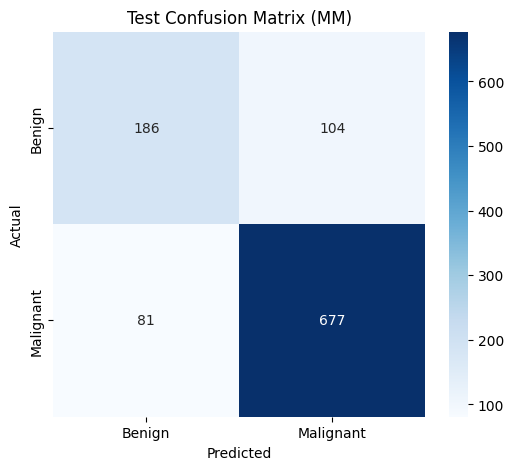

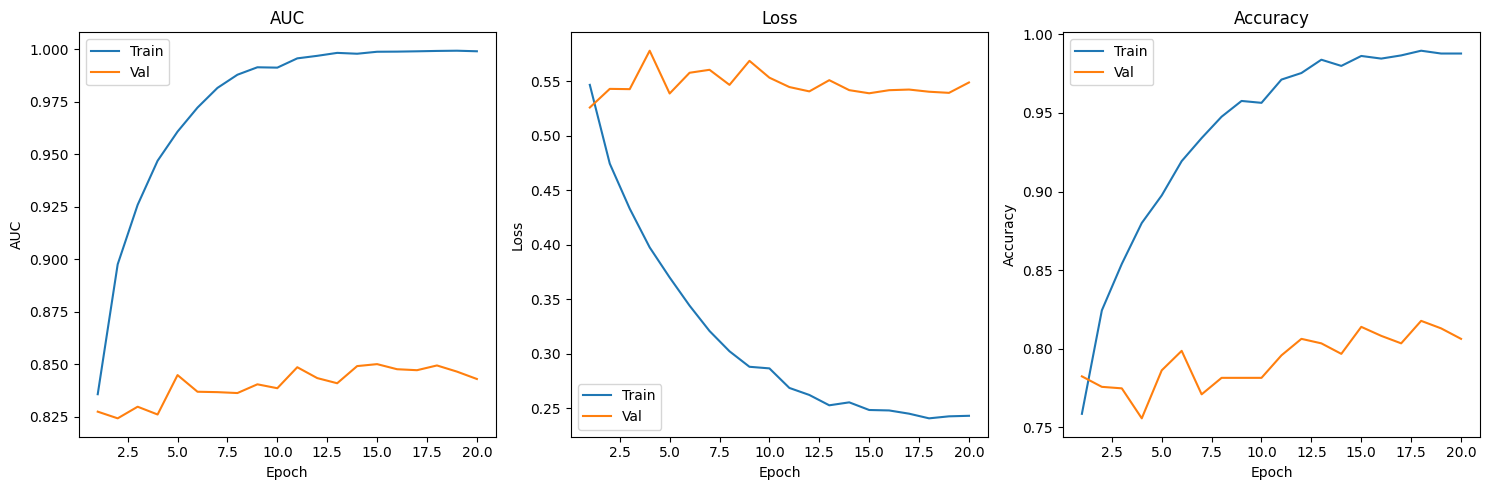

In [ ]:
import os, random, time, copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms

import timm
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# ── 1. CONFIGURATION & PATHS ──────────────────────────────────
SAVE_DIR = Path('/content/drive/MyDrive/Model_results')
SAVE_DIR.mkdir(parents=True, exist_ok=True)

IMAGE_DIR       = Path('/content/MILK10k_images/MILK10k_Training_Input')
METADATA_CSV    = Path('/content/drive/MyDrive/DS 4002 - Project 3/MILK10k_Training_Metadata.csv')
GROUNDTRUTH_CSV = Path('/content/drive/MyDrive/DS 4002 - Project 3/MILK10k_Training_GroundTruth.csv')

CFG = dict(
    img_size      = 224,
    batch_size    = 32,
    num_workers   = 2,
    num_epochs    = 20,
    lr            = 1e-4,
    weight_decay  = 1e-4,
    dropout       = 0.4,
    test_split    = 0.2,
    seed          = 42,
)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def seed_everything(seed):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)

seed_everything(CFG['seed'])

# ── 2. DATA PREPARATION (BINARY IMAGE + METADATA) ─────────────
meta = pd.read_csv(METADATA_CSV)
gt   = pd.read_csv(GROUNDTRUTH_CSV)

MALIGNANT_CLASSES = ['AKIEC', 'BCC', 'MAL_OTH', 'MEL', 'SCCKA']
ORIG_CLASS_COLS = ['AKIEC', 'BCC', 'BEN_OTH', 'BKL', 'DF', 'INF', 'MAL_OTH', 'MEL', 'NV', 'SCCKA', 'VASC']
gt['label'] = gt[ORIG_CLASS_COLS].idxmax(axis=1).apply(lambda x: 1 if x in MALIGNANT_CLASSES else 0)

df = meta.merge(gt[['lesion_id', 'label']], on='lesion_id', how='inner')
df['age_approx'] = df['age_approx'].fillna(df['age_approx'].mean())
df['site'] = df['site'].fillna('unknown')

df_encoded = pd.get_dummies(df, columns=['site', 'sex'], dummy_na=False)
meta_cols = [c for c in df_encoded.columns if c.startswith(('site_', 'sex_', 'age_approx'))]
META_DIM = len(meta_cols)

unique_lesions = df_encoded.drop_duplicates(subset='lesion_id')
train_l, temp_l = train_test_split(unique_lesions['lesion_id'], test_size=CFG['test_split'],
                                  stratify=unique_lesions['label'], random_state=CFG['seed'])
val_l, test_l = train_test_split(temp_l, test_size=0.50,
                                stratify=unique_lesions[unique_lesions['lesion_id'].isin(temp_l)]['label'],
                                random_state=CFG['seed'])

train_df = df_encoded[df_encoded['lesion_id'].isin(train_l)].reset_index(drop=True)
val_df   = df_encoded[df_encoded['lesion_id'].isin(val_l)].reset_index(drop=True)
test_df  = df_encoded[df_encoded['lesion_id'].isin(test_l)].reset_index(drop=True)

# ── 3. DATASET & TRANSFORMATIONS ─────────────────────────────
class ISICDatasetMM(Dataset):
    def __init__(self, dataframe, image_dir, meta_cols, transform=None):
        self.df, self.image_dir, self.meta_cols, self.transform = dataframe, Path(image_dir), meta_cols, transform
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = None
        for ext in ('.jpg', '.jpeg', '.png', '.JPG'):
            p = self.image_dir / str(row['lesion_id']) / f"{row['isic_id']}{ext}"
            if p.exists():
                img = Image.open(p).convert('RGB')
                break
        if img is None: img = Image.new('RGB', (CFG['img_size'], CFG['img_size']))
        if self.transform: img = self.transform(img)
        meta_data = torch.tensor(row[self.meta_cols].values.astype(np.float32))
        return img, meta_data, int(row['label'])

train_tfm = transforms.Compose([
    transforms.Resize((CFG['img_size']+32, CFG['img_size']+32)),
    transforms.RandomCrop(CFG['img_size']),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

eval_tfm = transforms.Compose([
    transforms.Resize((CFG['img_size'], CFG['img_size'])),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

# ── 4. MODEL ─────────────────────────────────────────────────
class ISICModelMM(nn.Module):
    def __init__(self, num_classes=2, meta_dim=META_DIM, dropout=0.4):
        super().__init__()
        self.backbone = timm.create_model('efficientnet_b0', pretrained=True, num_classes=0)
        img_dim = self.backbone.num_features
        self.meta_net = nn.Sequential(nn.Linear(meta_dim, 64), nn.BatchNorm1d(64), nn.ReLU(), nn.Dropout(dropout/2))
        self.head = nn.Sequential(nn.Linear(img_dim + 64, 512), nn.BatchNorm1d(512), nn.ReLU(),
                                  nn.Dropout(dropout), nn.Linear(512, num_classes))
    def forward(self, x, m):
        x = self.backbone.forward_features(x)
        x = nn.AdaptiveAvgPool2d(1)(x).flatten(1)
        m = self.meta_net(m)
        return self.head(torch.cat((x, m), dim=1))

# ── 5. TRAINING HELPER ───────────────────────────────────────
def run_epoch(model, loader, criterion, optimizer=None, phase='train'):
    model.train() if phase == 'train' else model.eval()
    running_loss, correct, total = 0.0, 0, 0
    all_labels, all_probs = [], []
    with torch.set_grad_enabled(phase == 'train'):
        for imgs, metas, labels in loader:
            imgs, metas, labels = imgs.to(DEVICE), metas.to(DEVICE), labels.to(DEVICE)
            logits = model(imgs, metas)
            loss = criterion(logits, labels)
            if phase == 'train' and optimizer is not None:
                optimizer.zero_grad(); loss.backward(); optimizer.step()
            probs = torch.softmax(logits, dim=1)
            running_loss += loss.item() * imgs.size(0)
            correct += (probs.argmax(dim=1) == labels).sum().item()
            total += imgs.size(0)
            all_labels.extend(labels.cpu().numpy()); all_probs.extend(probs.detach().cpu().numpy())
    auc = roc_auc_score(all_labels, np.array(all_probs)[:, 1])
    return running_loss/total, correct/total, auc, all_labels, all_probs

# ── 6. EXECUTION ──────────────────────────────────────────────
train_loader = DataLoader(ISICDatasetMM(train_df, IMAGE_DIR, meta_cols, train_tfm), batch_size=CFG['batch_size'], sampler=WeightedRandomSampler(1./np.bincount(train_df['label'])[train_df['label'].values], len(train_df)), num_workers=CFG['num_workers'])
val_loader = DataLoader(ISICDatasetMM(val_df, IMAGE_DIR, meta_cols, eval_tfm), batch_size=CFG['batch_size'], shuffle=False)
test_loader = DataLoader(ISICDatasetMM(test_df, IMAGE_DIR, meta_cols, eval_tfm), batch_size=CFG['batch_size'], shuffle=False)

model = ISICModelMM().to(DEVICE)
optimizer = optim.AdamW(model.parameters(), lr=CFG['lr'], weight_decay=CFG['weight_decay'])
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CFG['num_epochs'])
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

history = {'epoch':[], 'tr_auc':[], 'vl_auc':[], 'tr_loss':[], 'vl_loss':[], 'tr_acc':[], 'vl_acc':[]}
best_val_auc = 0.0

for epoch in range(1, CFG['num_epochs'] + 1):
    t0 = time.time()
    tr_loss, tr_acc, tr_auc, _, _ = run_epoch(model, train_loader, criterion, optimizer, 'train')
    vl_loss, vl_acc, vl_auc, _, _ = run_epoch(model, val_loader, criterion, None, 'val')
    scheduler.step()
    for k, v in zip(history.keys(), [epoch, tr_auc, vl_auc, tr_loss, vl_loss, tr_acc, vl_acc]): history[k].append(v)

    print(f"--- Epoch {epoch:02d} Summary ---")
    print(f"TRAIN | Loss: {tr_loss:.4f} | Acc: {tr_acc:.4f} | AUC: {tr_auc:.4f}")
    print(f"VAL   | Loss: {vl_loss:.4f} | Acc: {vl_acc:.4f} | AUC: {vl_auc:.4f}")
    print(f"Time  | {time.time()-t0:.1f}s")

    if vl_auc > best_val_auc:
        best_val_auc = vl_auc
        print(f"✅ Saving best model based on Val AUC: {best_val_auc:.4f}\n")
        torch.save(model.state_dict(), SAVE_DIR / 'best_binary_mm_model.pth')
    else:
        print("\n")

# ── 7. FINAL EVALUATION ──────────────────────────────────────
print('\n--- Final Evaluation (Multimodal) ---')
model.load_state_dict(torch.load(SAVE_DIR / 'best_binary_mm_model.pth'))
ts_loss, ts_acc, ts_auc, ts_labels, ts_probs = run_epoch(model, test_loader, criterion, phase='test')
ts_preds = np.array(ts_probs).argmax(axis=1)
print(f'Test AUC: {ts_auc:.4f} | Test Acc: {ts_acc:.4f}')
print(classification_report(ts_labels, ts_preds, target_names=['Benign', 'Malignant']))

cm = confusion_matrix(ts_labels, ts_preds)
plt.figure(figsize=(6,5));
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Benign', 'Malignant'], yticklabels=['Benign', 'Malignant'])
plt.title('Test Confusion Matrix (MM)'); plt.ylabel('Actual'); plt.xlabel('Predicted'); plt.show()

epochs = history['epoch']
plt.figure(figsize=(15,5))
plt.subplot(1,3,1); plt.plot(epochs, history['tr_auc'], label='Train'); plt.plot(epochs, history['vl_auc'], label='Val'); plt.title('AUC'); plt.xlabel('Epoch'); plt.ylabel('AUC'); plt.legend()
plt.subplot(1,3,2); plt.plot(epochs, history['tr_loss'], label='Train'); plt.plot(epochs, history['vl_loss'], label='Val'); plt.title('Loss'); plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend()
plt.subplot(1,3,3); plt.plot(epochs, history['tr_acc'], label='Train'); plt.plot(epochs, history['vl_acc'], label='Val'); plt.title('Accuracy'); plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend()
plt.tight_layout(); plt.savefig(SAVE_DIR / 'binary_mm_plots.png'); plt.show()